# 6 · Temporal products & statistical series

`TimeSeries` / `Climatology` over a `DatasetCollection`, and the `series` helpers (`envelope`, `quantile_band`, `boxplot`, `multiboxplot`, `stripes`) plus `Map.spaghetti`.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample data is found whether this runs
# from docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "acc4000.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RASTER = str(ROOT / "examples" / "data" / "acc4000.tif")
POINTS = str(ROOT / "tests" / "data" / "points.geojson")
print("data root:", ROOT)

data root: C:\gdrive\algorithms\Visualization\Digital-Earth


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyramids.dataset.collection import DatasetCollection
from digitalearth import series
from digitalearth.temporal import TimeSeries, Climatology

dc = DatasetCollection.from_files([RASTER] * 6)

2026-05-28 00:31:06 | INFO | pyramids.base.config | Logging is configured.


## TimeSeries — per-step spatial mean

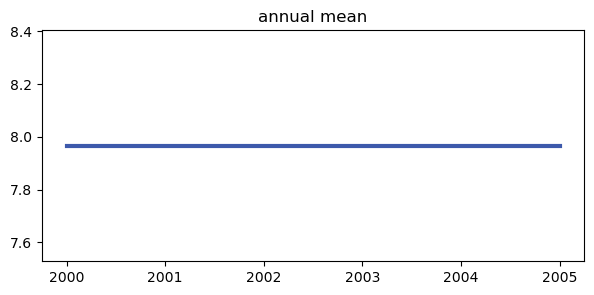

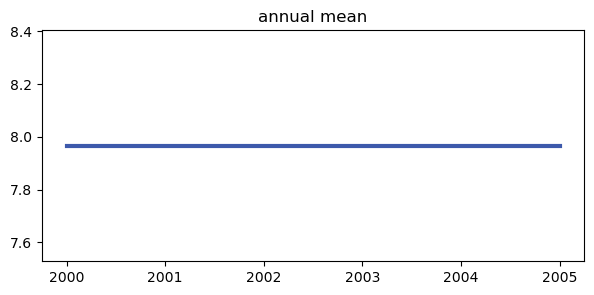

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
TimeSeries(dc).plot(times=[2000, 2001, 2002, 2003, 2004, 2005], ax=ax)
ax.set_title('annual mean')
fig

## Climatology — group means + spread plume

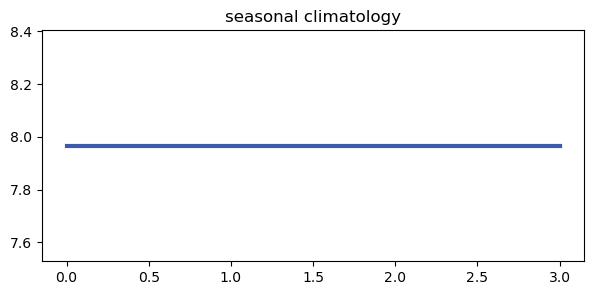

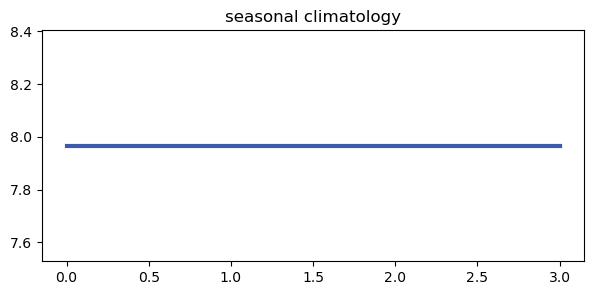

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
Climatology(dc, ['DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM']).plot(ax=ax)
ax.set_title('seasonal climatology')
fig

## Ensemble band (quantiles) and box plots

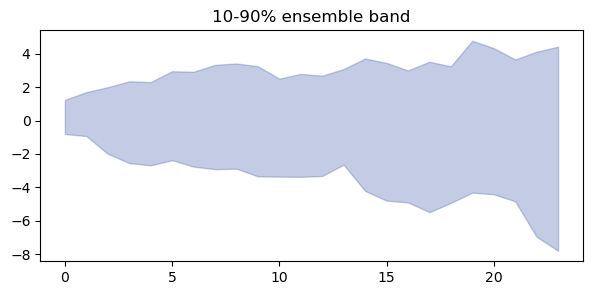

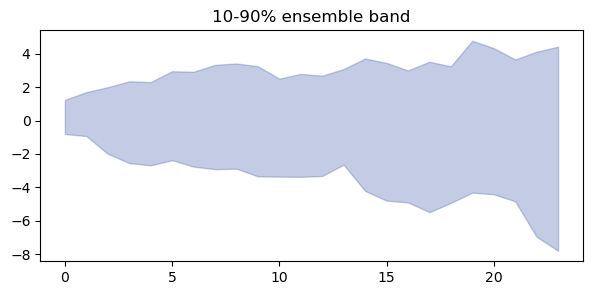

In [5]:
rng = np.random.default_rng(0)
ensemble = rng.normal(size=(30, 24)).cumsum(axis=1)
fig, ax = plt.subplots(figsize=(7, 3))
series.quantile_band(ensemble, lower=0.1, upper=0.9, ax=ax, alpha=0.3)
ax.set_title('10-90% ensemble band')
fig

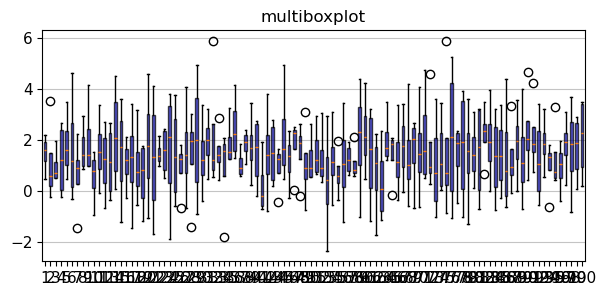

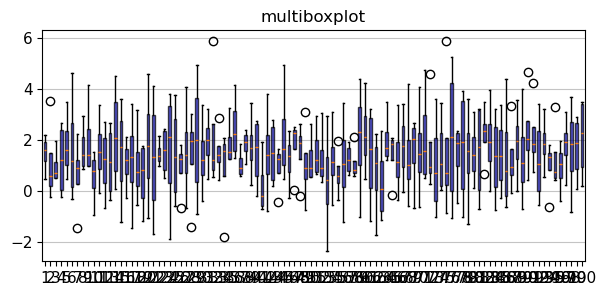

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
series.multiboxplot([rng.normal(m, 1, 100) for m in range(4)], ax=ax)
ax.set_title('multiboxplot')
fig

## Warming stripes

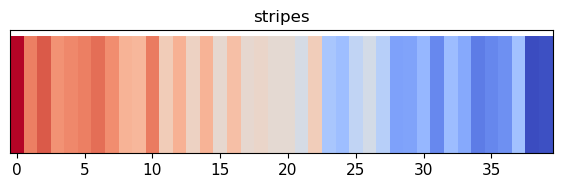

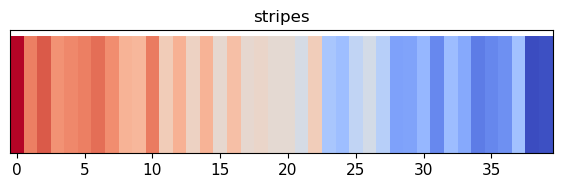

In [7]:
fig, ax = plt.subplots(figsize=(7, 1.6))
series.stripes(np.linspace(-1, 1, 40) + rng.normal(0, 0.2, 40), ax=ax)
ax.set_title('stripes')
fig